# 📌🏭 Smart Factory Machine Performance & Predictive Maintenance


📌 **Objective:** To analyze smart factory machine data, monitor machine performance, study sensor parameters, energy consumption, maintenance status and failure risk, and generate useful insights for predictive maintenance.

📌 **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

# 1). Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# # 2). Load Smart Factory Dataset

In [3]:
file_path = r"C:\Users\HP\smart_factory_cleaned.csv"

df = pd.read_csv(file_path)

df.head()

,Machine_ID,Timestamp,Temperature_C,Vibration_mm_s,Pressure_bar,Energy_Consumption_kWh,Operating_Hours,Machine_Status,Maintenance_Status,Failure_Risk
0,M007,2026-01-01 08:00:00,69.81,6.25,79.24,137.52,715,Running,Inspection,Low
1,M004,2026-01-01 11:00:00,53.57,3.41,74.00,157.97,737,Running,Normal,Low
2,M008,2026-01-01 14:00:00,54.12,5.22,74.79,134.93,900,Running,Normal,Low
3,M005,2026-01-01 17:00:00,63.84,2.77,76.59,215.11,84,Running,Inspection,Low
4,M007,2026-01-01 20:00:00,56.58,3.35,74.65,166.84,672,Running,Normal,Low


# 3). View First 5 Records

In [4]:
df.head()

,Machine_ID,Timestamp,Temperature_C,Vibration_mm_s,Pressure_bar,Energy_Consumption_kWh,Operating_Hours,Machine_Status,Maintenance_Status,Failure_Risk
0,M007,2026-01-01 08:00:00,69.81,6.25,79.24,137.52,715,Running,Inspection,Low
1,M004,2026-01-01 11:00:00,53.57,3.41,74.00,157.97,737,Running,Normal,Low
2,M008,2026-01-01 14:00:00,54.12,5.22,74.79,134.93,900,Running,Normal,Low
3,M005,2026-01-01 17:00:00,63.84,2.77,76.59,215.11,84,Running,Inspection,Low
4,M007,2026-01-01 20:00:00,56.58,3.35,74.65,166.84,672,Running,Normal,Low


 # 4). View Last 5 Records

In [5]:
df.tail()

,Machine_ID,Timestamp,Temperature_C,Vibration_mm_s,Pressure_bar,Energy_Consumption_kWh,Operating_Hours,Machine_Status,Maintenance_Status,Failure_Risk
995,M010,2026-05-05 17:00:00,58.08,1.25,79.36,149.71,225,Running,Normal,Low
996,M010,2026-05-05 20:00:00,52.14,2.59,68.15,131.27,354,Running,Normal,Low
997,M008,2026-05-05 23:00:00,60.04,6.06,74.86,115.18,542,Running,Inspection,Low
998,M002,2026-06-05 02:00:00,51.88,1.92,80.66,124.27,893,Running,Normal,Low
999,M009,2026-06-05 05:00:00,67.85,4.33,81.65,142.12,437,Running,Normal,Low


# 5). Dataset Shape

In [6]:
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 1000
Number of Columns: 10


# 6). Dataset Column Names

In [7]:
df.columns

Index(['Machine_ID', 'Timestamp', 'Temperature_C', 'Vibration_mm_s',
       'Pressure_bar', 'Energy_Consumption_kWh', 'Operating_Hours',
       'Machine_Status', 'Maintenance_Status', 'Failure_Risk'],
      dtype='object')

# 7). Check Data Types

In [10]:
df.dtypes

Machine_ID                 object
Timestamp                  object
Temperature_C             float64
Vibration_mm_s            float64
Pressure_bar              float64
Energy_Consumption_kWh    float64
Operating_Hours             int64
Machine_Status             object
Maintenance_Status         object
Failure_Risk               object
dtype: object

# 8). Missing Value Analysis

In [11]:
df.isnull().sum()

Machine_ID                0
Timestamp                 0
Temperature_C             0
Vibration_mm_s            0
Pressure_bar              0
Energy_Consumption_kWh    0
Operating_Hours           0
Machine_Status            0
Maintenance_Status        0
Failure_Risk              0
dtype: int64

# 9). Duplicate Row Check

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 10). Convert Timestamp

In [13]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="mixed")

df.dtypes

Machine_ID                        object
Timestamp                 datetime64[ns]
Temperature_C                    float64
Vibration_mm_s                   float64
Pressure_bar                     float64
Energy_Consumption_kWh           float64
Operating_Hours                    int64
Machine_Status                    object
Maintenance_Status                object
Failure_Risk                      object
dtype: object

# 11). Statistical Summary

In [14]:
df.describe()

,Timestamp,Temperature_C,Vibration_mm_s,Pressure_bar,Energy_Consumption_kWh,Operating_Hours
count,1000,1000.00000,1000.000000,1000.00000,1000.000000,1000.00000
mean,2026-04-16 15:08:24,62.09664,3.907910,71.85463,145.214790,625.26800
min,2026-01-01 08:00:00,29.89000,-0.570000,49.32000,62.790000,51.00000
25%,2026-02-15 13:15:00,56.17500,2.890000,67.32500,127.000000,348.75000
50%,2026-03-25 18:30:00,62.26000,3.935000,72.00000,144.910000,635.00000
75%,2026-05-02 23:45:00,68.57500,4.950000,76.63750,163.122500,895.00000
max,2026-12-04 23:00:00,90.28000,8.690000,91.26000,247.420000,1200.00000
std,NaN,9.21459,1.563755,6.85959,27.524153,329.43861


# 12). Machine Status Analysis

In [15]:
df["Machine_Status"].value_counts()

Machine_Status
Running    799
Idle       195
Alert        6
Name: count, dtype: int64

# 13). Machine Status Distribution

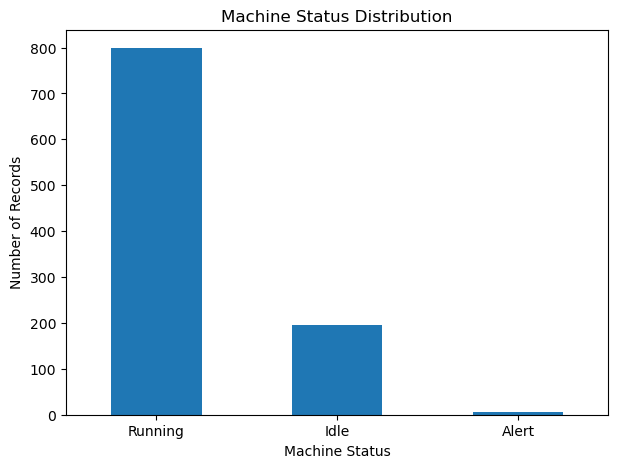

In [16]:
plt.figure(figsize=(7,5))

df["Machine_Status"].value_counts().plot(kind="bar")

plt.title("Machine Status Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

# 14). Failure Risk Analysis

In [17]:
df["Failure_Risk"].value_counts()

Failure_Risk
Low       906
Medium     88
High        6
Name: count, dtype: int64

# 15). Failure Risk Distribution

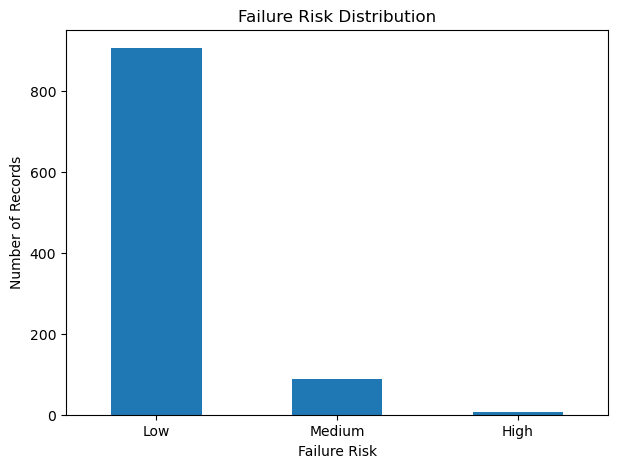

In [18]:
plt.figure(figsize=(7,5))

df["Failure_Risk"].value_counts().plot(kind="bar")

plt.title("Failure Risk Distribution")
plt.xlabel("Failure Risk")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

# 16). Temperature Trend Analysis

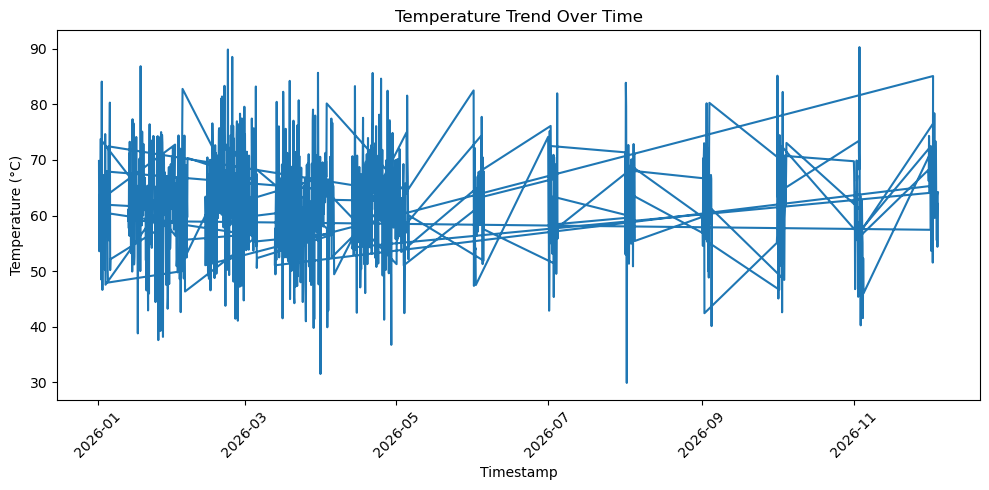

In [19]:
plt.figure(figsize=(10,5))

plt.plot(df["Timestamp"], df["Temperature_C"])

plt.title("Temperature Trend Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 17). Energy Consumption Analysis

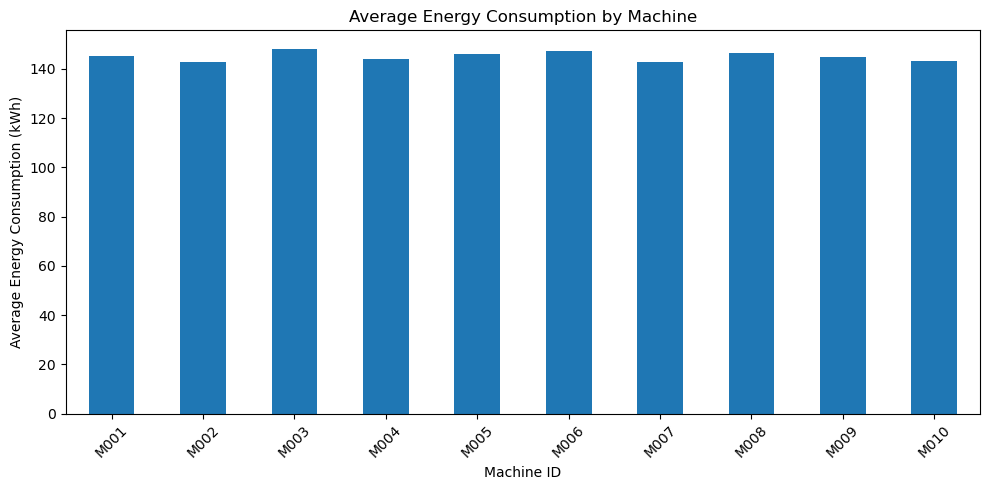

In [20]:
energy_by_machine = df.groupby("Machine_ID")["Energy_Consumption_kWh"].mean()

plt.figure(figsize=(10,5))

energy_by_machine.plot(kind="bar")

plt.title("Average Energy Consumption by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Average Energy Consumption (kWh)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 18). Operating Hours Analysis

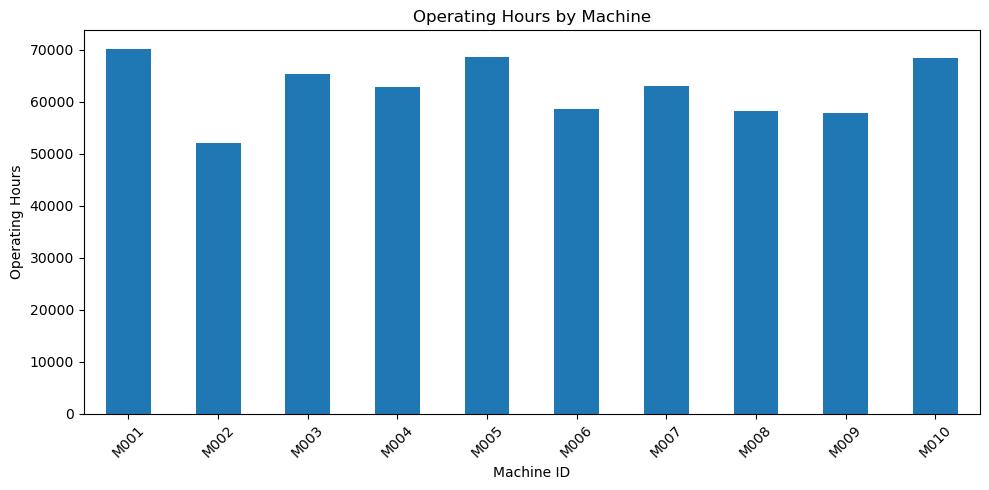

In [21]:
hours_by_machine = df.groupby("Machine_ID")["Operating_Hours"].sum()

plt.figure(figsize=(10,5))

hours_by_machine.plot(kind="bar")

plt.title("Operating Hours by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Operating Hours")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 19). Vibration Analysis

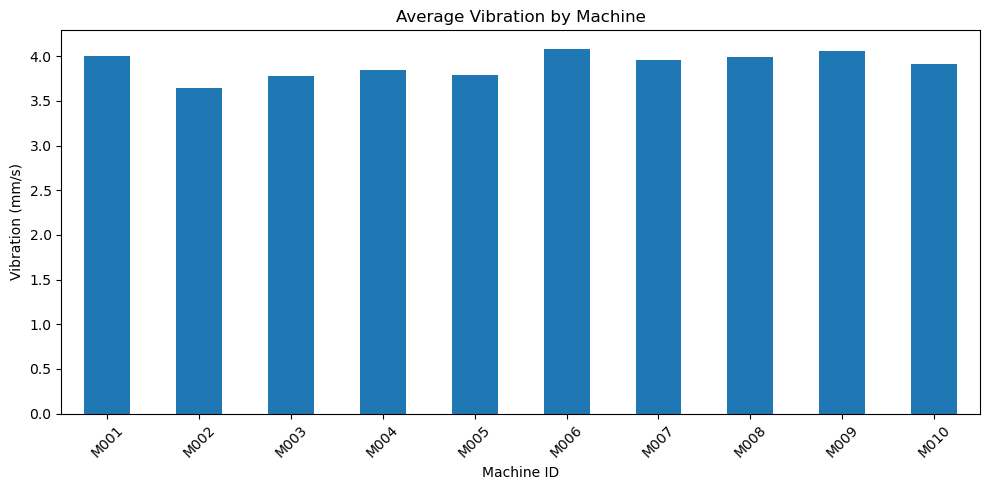

In [22]:
vibration_by_machine = df.groupby("Machine_ID")["Vibration_mm_s"].mean()

plt.figure(figsize=(10,5))

vibration_by_machine.plot(kind="bar")

plt.title("Average Vibration by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Vibration (mm/s)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 20). Maintenance Status Analysis

In [23]:
df["Maintenance_Status"].value_counts()

Maintenance_Status
Normal        562
Inspection    344
Required       94
Name: count, dtype: int64

# 21). Maintenance Status Distribution

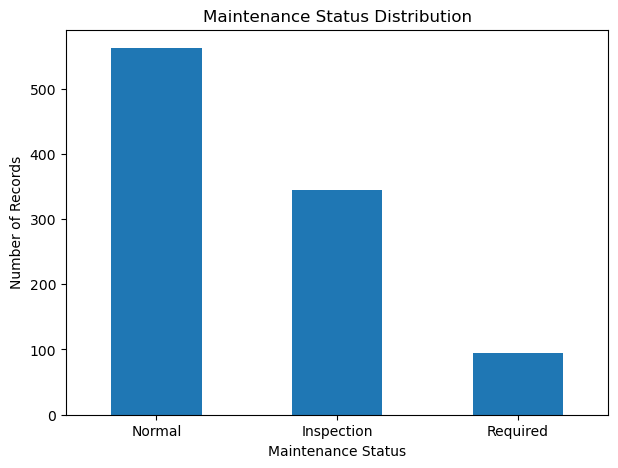

In [24]:
plt.figure(figsize=(7,5))

df["Maintenance_Status"].value_counts().plot(kind="bar")

plt.title("Maintenance Status Distribution")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.show()

# 22). Sensor Parameter Correlation

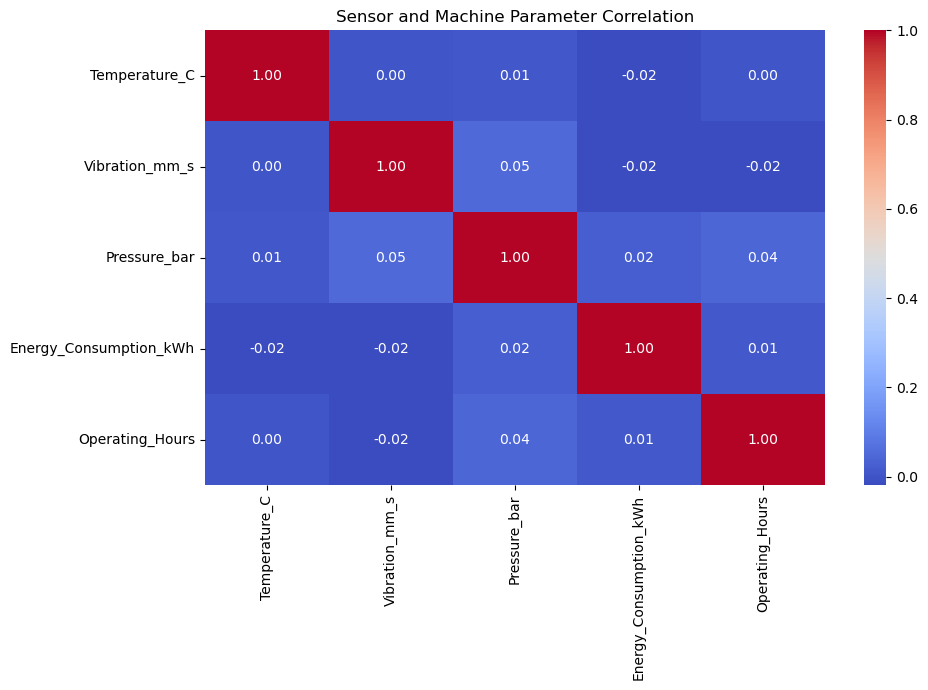

In [25]:
numeric_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Sensor and Machine Parameter Correlation")

plt.tight_layout()
plt.show()

# 23). Energy Consumption vs Operating Hours

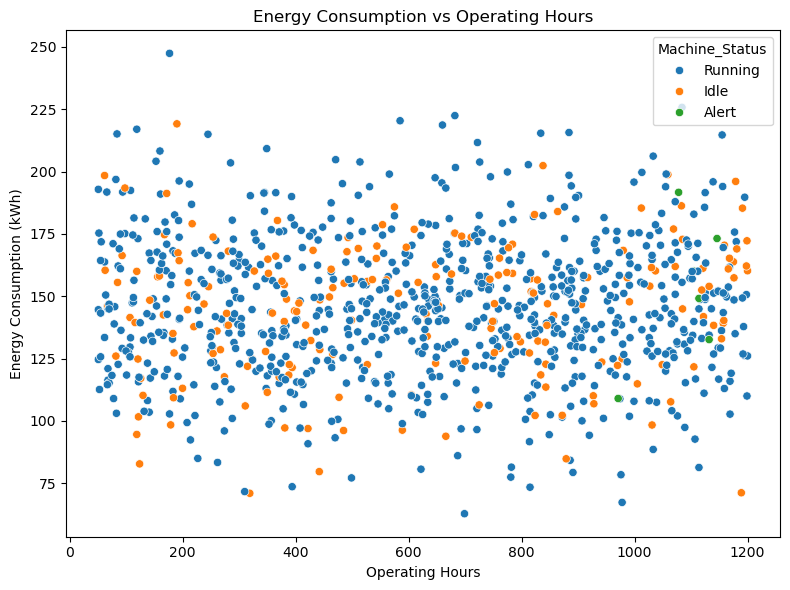

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Operating_Hours",
    y="Energy_Consumption_kWh",
    hue="Machine_Status"
)

plt.title("Energy Consumption vs Operating Hours")
plt.xlabel("Operating Hours")
plt.ylabel("Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

# 24). Machine-wise Performance Summary

In [27]:
machine_summary = df.groupby("Machine_ID").agg({
    "Temperature_C": "mean",
    "Vibration_mm_s": "mean",
    "Pressure_bar": "mean",
    "Energy_Consumption_kWh": "mean",
    "Operating_Hours": "sum"
})

machine_summary

,Temperature_C,Vibration_mm_s,Pressure_bar,Energy_Consumption_kWh,Operating_Hours
Machine_ID,,,,,
M001,61.793898,3.997373,71.534576,145.459068,70216
M002,64.109277,3.640723,73.374337,142.795422,52107
M003,63.277000,3.778636,71.146364,148.271273,65280
M004,61.882447,3.845638,71.878617,143.920213,62809
M005,62.284019,3.792056,72.261308,146.174299,68664
M006,62.888750,4.086042,72.379375,147.422396,58684
M007,62.282660,3.955106,71.613830,142.631809,63075
M008,61.219600,3.992700,71.120100,146.496700,58147
M009,60.191648,4.058571,71.929011,144.967033,57870


# 25). Machine Energy Efficiency Analysis

In [28]:
energy_efficiency = df.groupby("Machine_ID").agg({
    "Energy_Consumption_kWh": "mean",
    "Operating_Hours": "mean"
})

energy_efficiency["Energy_per_Operating_Hour"] = (
    energy_efficiency["Energy_Consumption_kWh"] /
    energy_efficiency["Operating_Hours"]
)

energy_efficiency

,Energy_Consumption_kWh,Operating_Hours,Energy_per_Operating_Hour
Machine_ID,,,
M001,145.459068,595.050847,0.244448
M002,142.795422,627.795181,0.227455
M003,148.271273,593.454545,0.249844
M004,143.920213,668.180851,0.215391
M005,146.174299,641.719626,0.227785
M006,147.422396,611.291667,0.241165
M007,142.631809,671.010638,0.212563
M008,146.496700,581.470000,0.251942
M009,144.967033,635.934066,0.227959


# 26). Failure Risk by Machine

In [29]:
failure_by_machine = pd.crosstab(
    df["Machine_ID"],
    df["Failure_Risk"]
)

failure_by_machine

Failure_Risk,High,Low,Medium
Machine_ID,,,
M001,1,108,9
M002,2,71,10
M003,0,104,6
M004,1,86,7
M005,0,98,9
M006,0,83,13
M007,1,87,6
M008,1,92,7
M009,0,80,11


# 27). Final Dataset Validation

In [30]:
print("Final Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (1000, 10)
Total Missing Values: 0
Duplicate Rows: 0


# 🎯 28). Conclusion

The Smart Factory Analytics project analyzes machine performance,
sensor parameters, energy consumption, operating hours,
maintenance status, and failure risk.

The dataset was cleaned and analyzed using Python libraries such as
Pandas, NumPy, Matplotlib, and Seaborn.

The analysis provides useful insights into machine performance,
energy usage, maintenance requirements, and potential failure risks.

The analyzed data is further used to create an interactive
Power BI dashboard for smart factory monitoring and
predictive maintenance analysis.

By Shraddha..